<a href="https://colab.research.google.com/github/SohamDahanukar/Auralis/blob/main/rl_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

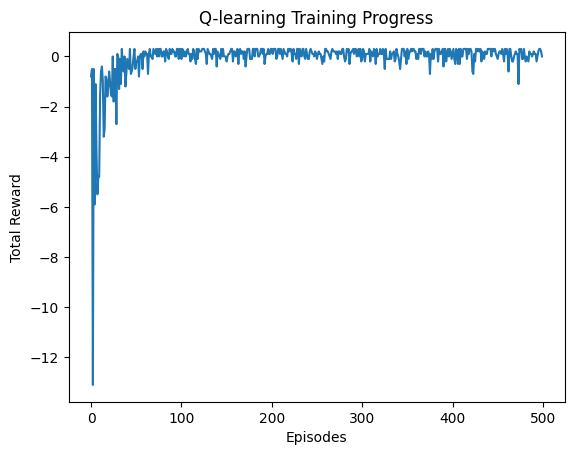

Learned Policy:
↓ ↓ ↓ → ↓
↓ ↓ → → ↓
→ ↓ X → ↓
→ ↓ ↓ X ↓
→ → → → G


In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Define the GridWorld Environment
class GridWorld:
    def __init__(self, size=5, goal=(4, 4), obstacles=[(2, 2), (3, 3)]):
        self.size = size
        self.goal = goal
        self.obstacles = obstacles
        self.state = (0, 0)
        self.actions = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # Right, Left, Down, Up

    def reset(self):
        self.state = (0, 0)
        return self.state

    def step(self, action):
        new_state = (self.state[0] + action[0], self.state[1] + action[1])
        if new_state in self.obstacles or not (0 <= new_state[0] < self.size and 0 <= new_state[1] < self.size):
            new_state = self.state  # Invalid move

        reward = 1 if new_state == self.goal else -0.1
        done = new_state == self.goal
        self.state = new_state
        return new_state, reward, done

# Q-Learning Agent
class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.2, episodes=500):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.episodes = episodes
        self.q_table = np.zeros((env.size, env.size, len(env.actions)))

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.env.actions)
        else:
            state_idx = (state[0], state[1])
            return self.env.actions[np.argmax(self.q_table[state_idx])]

    def train(self):
        rewards = []
        for _ in range(self.episodes):
            state = self.env.reset()
            total_reward = 0
            done = False

            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                action_idx = self.env.actions.index(action)
                next_action_idx = np.argmax(self.q_table[next_state])

                # Q-learning update rule
                self.q_table[state][action_idx] += self.alpha * (
                    reward + self.gamma * self.q_table[next_state][next_action_idx] - self.q_table[state][action_idx]
                )

                state = next_state
                total_reward += reward
            rewards.append(total_reward)
        return rewards

    def visualize_policy(self):
        policy_grid = np.full((self.env.size, self.env.size), '•', dtype=str)
        action_symbols = {(0, 1): '→', (0, -1): '←', (1, 0): '↓', (-1, 0): '↑'}

        for i in range(self.env.size):
            for j in range(self.env.size):
                if (i, j) in self.env.obstacles:
                    policy_grid[i, j] = 'X'  # Obstacle
                elif (i, j) == self.env.goal:
                    policy_grid[i, j] = 'G'  # Goal
                else:
                    best_action_idx = np.argmax(self.q_table[i, j])
                    policy_grid[i, j] = action_symbols[self.env.actions[best_action_idx]]

        print("Learned Policy:")
        for row in policy_grid:
            print(' '.join(row))

# Initialize and Train Agent
env = GridWorld()
agent = QLearningAgent(env)
rewards = agent.train()

# Plot Learning Curve
plt.plot(rewards)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Q-learning Training Progress')
plt.show()

# Visualize Learned Policy
agent.visualize_policy()
